In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split,cross_val_score,cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,r2_score

In [2]:
df=pd.read_csv("Crop_recommendation.csv")

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.shape

(2200, 8)

In [8]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [9]:
fertility_mapping = {
    'rice': 2,
    'maize': 2,
    'chickpea': 0,
    'kidneybeans': 1,
    'pigeonpeas': 0,
    'mothbeans': 0,
    'mungbean': 0,
    'blackgram': 0,
    'lentil': 0,
    'pomegranate': 1,
    'banana': 2,
    'mango': 1,
    'grapes': 2,
    'watermelon': 1,
    'muskmelon': 1,
    'apple': 1,
    'orange': 1,
    'papaya': 1,
    'coconut': 1,
    'cotton': 1,
    'jute': 2,
    'coffee': 2
}

In [10]:
df['soil_health']=df['label'].map(fertility_mapping)

In [14]:
col_to_move = 'label'
new_order = [col for col in df.columns if col != col_to_move] + [col_to_move]
df = df[new_order]

In [ ]:
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,soil_health,label
1851,18,19,29,27.593768,92.485196,6.206078,162.843274,1,coconut
2121,83,21,28,25.567483,60.492446,7.466901,190.225784,2,coffee
886,28,79,16,24.706264,60.268542,6.052185,53.124429,0,lentil
980,10,5,42,20.241049,91.087068,6.887006,109.253773,1,pomegranate
1342,86,6,53,25.920302,83.472026,6.921848,42.106815,1,watermelon


In [16]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall,soil_health
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,1.000000
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,0.738717
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,0.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,0.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,1.000000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,2.000000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,2.000000


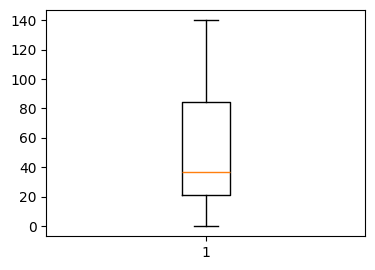

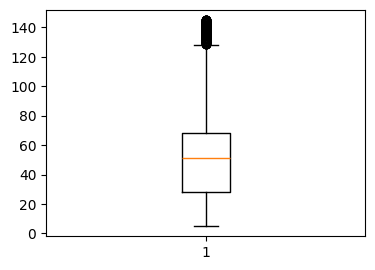

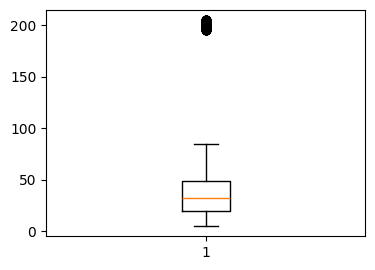

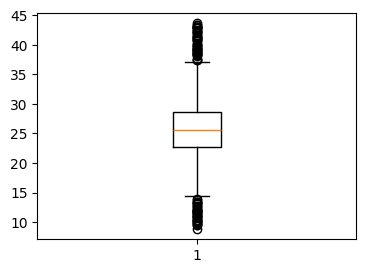

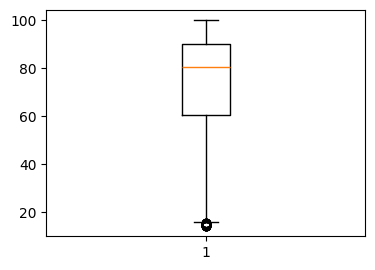

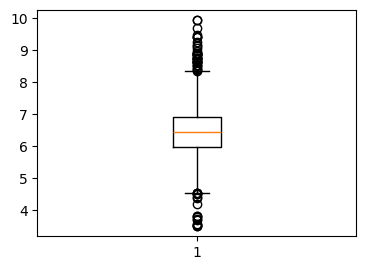

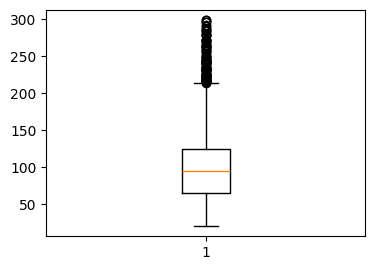

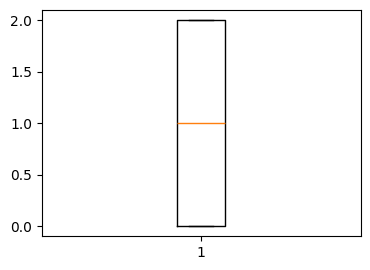

<Figure size 1400x1000 with 0 Axes>

In [24]:
for i,col in enumerate(df.columns,1):
    plt.figure(figsize=(14,10))
    if col !='label':
        plt.subplot(3,3,i)
        plt.boxplot(df[col])
        

In [27]:
new_df=df.drop('label',axis=1)

In [29]:
for i,col in enumerate(new_df.columns):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    upper_limit=Q3 + (1.5 * IQR)
    lower_limit=Q1 - (1.5 * IQR)
    df[col]=np.where(df[col]>upper_limit,upper_limit,np.where(df[col]<lower_limit,lower_limit,df[col]))

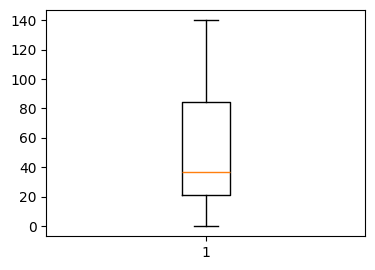

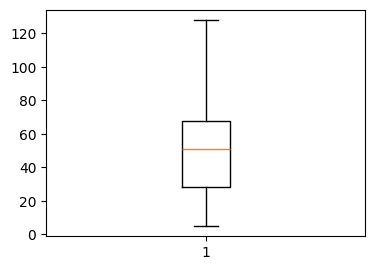

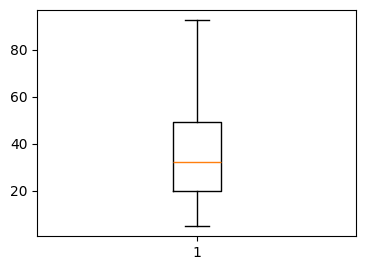

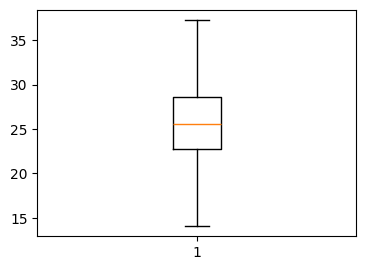

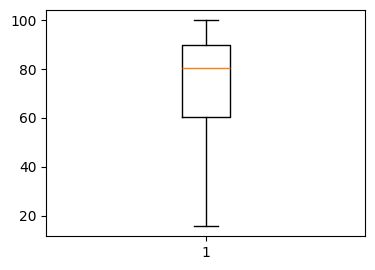

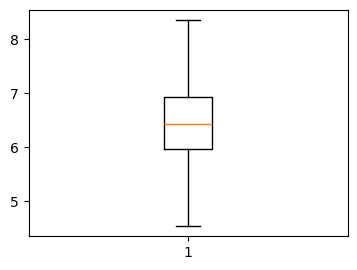

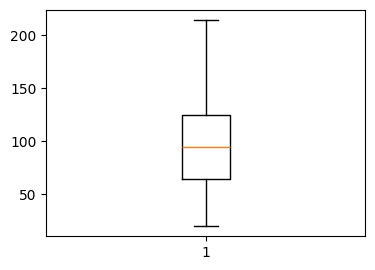

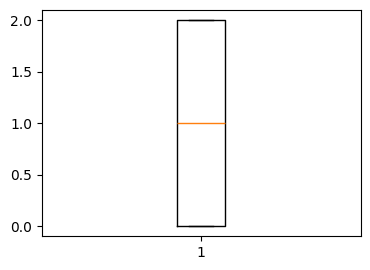

<Figure size 1400x1000 with 0 Axes>

In [30]:
for i,col in enumerate(df.columns,1):
    plt.figure(figsize=(14,10))
    if col !='label':
        plt.subplot(3,3,i)
        plt.boxplot(df[col])

In [33]:
X=df.drop('label',axis=1)
y=df['label']

In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [39]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
def train_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted') # Added average='weighted'
    recall = recall_score(y_test, y_pred, average='weighted') # Added average='weighted'
    f1 = f1_score(y_test, y_pred, average='weighted') # Added average='weighted'

    matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix is:")
    # print(matrix)


    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted No", "Predicted Yes"],
                yticklabels=["Actual No", "Actual Yes"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("\n\nScore Table is: ")
    score_df = pd.DataFrame([[accuracy, precision, recall, f1]],
                            columns=["accuracy", "precision", "recall", "f1"])

    return score_df

d:\anaconda\envs\campx\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix is:


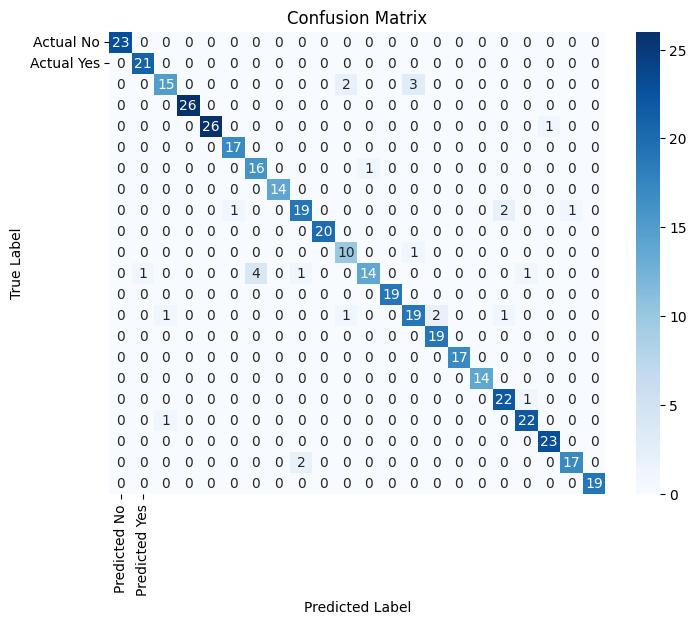



Score Table is: 


,accuracy,precision,recall,f1
Logistic Regression,0.936364,0.937726,0.936364,0.934994


In [40]:
model=LogisticRegression()
result=train_model(model,X_train, y_train, X_test, y_test)
result.index=["Logistic Regression"]
result

Confusion Matrix is:


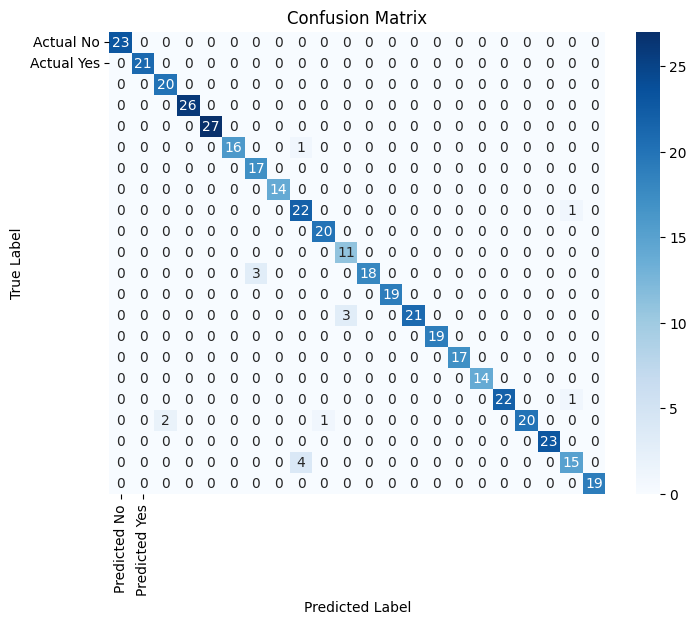



Score Table is: 


,accuracy,precision,recall,f1
SVC,0.963636,0.96779,0.963636,0.963837


In [41]:
model=SVC()
result=train_model(model,X_train, y_train, X_test, y_test)
result.index=["SVC"]
result

Confusion Matrix is:


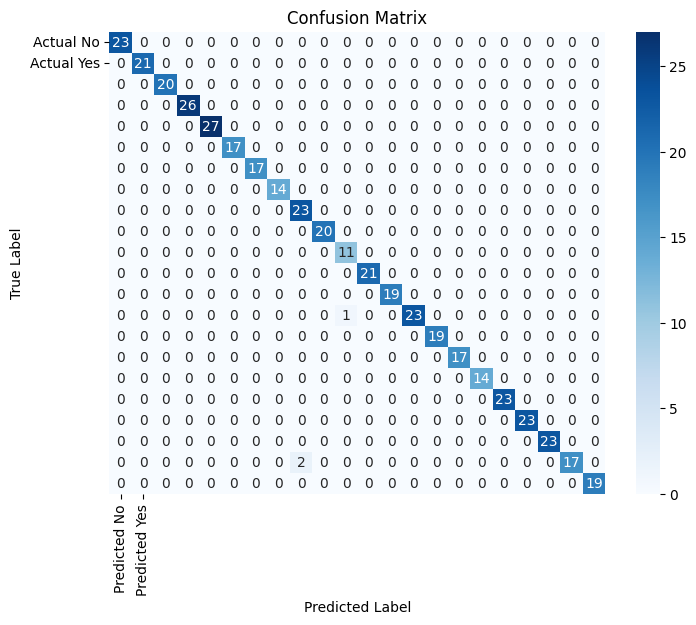



Score Table is: 


,accuracy,precision,recall,f1
Logistic Regression,0.993182,0.993735,0.993182,0.993175


In [42]:
model=RandomForestClassifier()
result=train_model(model,X_train, y_train, X_test, y_test)
result.index=["Logistic Regression"]
result

In [47]:
model=RandomForestClassifier(criterion='gini')
print(np.mean(cross_val_score(model,X,y,cv=5,scoring='accuracy')))

0.9950000000000001


In [49]:
import joblib
with open('crop_recomander_model.pkl','wb') as f:
    joblib.dump(model,f)
    

In [51]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

reverse_mapping = {v: k for k, v in label_mapping.items()}
print(reverse_mapping)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}
{np.int64(0): 'apple', np.int64(1): 'banana', np.int64(2): 'blackgram', np.int64(3): 'chickpea', np.int64(4): 'coconut', np.int64(5): 'coffee', np.int64(6): 'cotton', np.int64(7): 'grapes', np.int64(8): 'jute', np.int64(9): 'kidneybeans', np.int64(10): 'lentil', np.int64(11): 'maize', np.int64(12): 'mango', np.int64(13): 'mothbeans', np.int64(14): 'mungbean', np.int64(15): 'muskmelon', np.int64(16): 'orange', np.int64(17): 'papaya', np.int64(18): 'pige